# MENGUKUR JARAK (SIMILARITY & DISSIMILARITY)

## 1. Konsep Dasar

Dalam data mining, pengukuran jarak digunakan untuk mengetahui tingkat kemiripan atau perbedaan antar objek.

### 1.1 Similarity

Similarity adalah ukuran numerik yang menunjukkan seberapa mirip dua objek.

- Nilai tinggi → semakin mirip  
- Biasanya berada pada rentang [0,1]  
- Similarity maksimum = 1  

---

### 1.2 Dissimilarity (Distance)

Dissimilarity atau distance mengukur tingkat perbedaan antar objek.

- Nilai kecil → semakin mirip  
- Nilai minimum = 0 (jika objek identik)  
- Semakin besar → semakin berbeda  

Hubungan umum:  
Semakin besar similarity → semakin kecil distance.

---

# 2. Representasi Data

## 2.1 Data Matrix

Data direpresentasikan dalam bentuk matriks berukuran:

n × p

Dimana:
- n = jumlah objek
- p = jumlah atribut

Contoh:
1000 siswa × 10 atribut

---

## 2.2 Dissimilarity Matrix

Matriks yang berisi jarak antar setiap pasangan objek.

Sifat:
- Berbentuk matriks segitiga
- d(i,j) = d(j,i)
- d(i,i) = 0

---

# 3. Pengukuran Berdasarkan Jenis Atribut

---

## 3.1 Atribut Nominal

Digunakan untuk kategori tanpa urutan.

### Simple Matching

Rumus similarity:

$$
S = \frac{m}{p}
$$

Rumus dissimilarity:

$$
D = \frac{p - m}{p}
$$

Dimana:
- m = jumlah atribut yang sama
- p = jumlah total atribut

Semakin banyak kecocokan → semakin tinggi similarity.

---

## 3.2 Atribut Binary

### 3.2.1 Binary Simetris

$$
SMC = \frac{a + d}{a + b + c + d}
$$

Dimana:
- a = jumlah 1-1
- b = jumlah 1-0
- c = jumlah 0-1
- d = jumlah 0-0

---

### 3.2.2 Binary Asimetris (Jaccard)

$$
J = \frac{a}{a + b + c}
$$

Pasangan 0-0 tidak dihitung karena tidak informatif.

---

## 3.3 Atribut Ordinal

Normalisasi ranking:

$$
z_{if} = \frac{r_{if} - 1}{M_f - 1}
$$

Dimana:
- r_if = ranking objek ke-i
- M_f = jumlah kategori

Setelah dinormalisasi → diperlakukan seperti numerik.

---

## 3.4 Atribut Numerik

### Min-Max Normalization

$$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

---

### Z-Score Normalization

$$
z = \frac{x - \mu}{\sigma}
$$

---

# 4. Minkowski Distance (Generalisasi Jarak)

Minkowski Distance adalah bentuk umum dari pengukuran jarak pada data numerik multidimensi.

## Rumus Umum

$$
d(i,j) = \left( \sum_{f=1}^{p} |x_{if} - x_{jf}|^h \right)^{\frac{1}{h}}
$$

Dimana:
- i dan j = dua objek
- f = atribut ke-f
- p = jumlah atribut
- h = parameter pangkat (Lh norm)

---

## Cara Kerja

1. Hitung selisih tiap atribut
2. Pangkatkan dengan h
3. Jumlahkan seluruh atribut
4. Akar pangkat h dari hasilnya

Semakin kecil nilai d(i,j) → semakin mirip objek.

---

## Sifat Minkowski

1. $$ d(i,j) \ge 0 $$
2. $$ d(i,i) = 0 $$
3. $$ d(i,j) = d(j,i) $$
4. $$ d(i,j) \le d(i,k) + d(k,j) $$

---

## 4.1 Kasus Khusus Minkowski

### Manhattan Distance (h = 1)

$$
d(i,j) = \sum_{f=1}^{p} |x_{if} - x_{jf}|
$$

Menjumlahkan selisih absolut.

---

### Euclidean Distance (h = 2)

$$
d(i,j) = \sqrt{\sum_{f=1}^{p} (x_{if} - x_{jf})^2}
$$

Mengukur jarak garis lurus antar titik.

---

### Supremum Distance (h → ∞)

$$
d(i,j) = \max_{f} |x_{if} - x_{jf}|
$$

Mengambil selisih maksimum antar atribut.

---

# 5. Atribut Campuran (Mixed Data)

Jika dataset mengandung berbagai tipe data, gunakan pendekatan gabungan:

$$
d(i,j) = \frac{\sum_{f=1}^{p} w_f \, d_{if}}{\sum_{f=1}^{p} w_f}
$$

Dimana:
- w_f = bobot atribut
- d_if = jarak tiap atribut

Langkah:
1. Nominal/Binary → 0 jika sama, 1 jika beda  
2. Numerik → normalisasi  
3. Ordinal → ranking + normalisasi  

---

# 6. Cosine Similarity

Digunakan pada data teks.

$$
\cos(d_1, d_2) = \frac{d_1 \cdot d_2}{||d_1|| \, ||d_2||}
$$

Dengan:

$$
||d|| = \sqrt{\sum x^2}
$$

Nilai mendekati 1 → sangat mirip  
Nilai mendekati 0 → tidak mirip  

Cosine mengukur sudut antar vektor, bukan jarak absolut.

## 2. Implementasi Data Campuran (Mixed Data)

### 2.1 Deskripsi Umum Dataset

Dataset yang digunakan adalah **Student Performance Dataset** yang diambil dari Kaggle. Dataset ini berisi informasi mengenai performa akademik siswa berdasarkan faktor demografis dan latar belakang keluarga.

**Karakteristik dataset:**

- Jumlah data: ±1000 siswa
- Jumlah atribut: 10 kolom
- Setiap baris merepresentasikan 1 siswa
- Setiap kolom merepresentasikan atribut karakteristik siswa

Dataset ini termasuk **data campuran (mixed data)** karena terdiri dari:

- Data numerik
- Data ordinal
- Data kategorikal (nominal)
- Data biner

> Karena tipe datanya tidak seragam, diperlukan transformasi sebelum menghitung jarak.

---

### 2.2 Atribut Dataset

Berikut atribut yang digunakan:

1. gender  
2. race/ethnicity  
3. parental level of education  
4. lunch  
5. test preparation course  
6. math score  
7. reading score  
8. writing score  
9. education_level_ordinal  
10. math_score_level  

---

### 2.3 Klasifikasi Jenis Data

### A. Data Numerik
Merupakan data berbentuk angka yang dapat dihitung secara matematis.

- math score (0–100)  
- reading score (0–100)  
- writing score (0–100)  

> Atribut ini dapat langsung digunakan dalam perhitungan jarak seperti Euclidean dan Manhattan, namun tetap perlu normalisasi agar skala tidak mendominasi.

### B. Data Ordinal
Merupakan data kategori yang memiliki tingkatan.

1. **education_level_ordinal**  
   Skala pendidikan orang tua:  

1 = some high school
2 = high school
3 = some college
4 = associate’s degree
5 = bachelor’s degree
6 = master’s degree

Semakin tinggi nilai → semakin tinggi tingkat pendidikan.

2. **math_score_level**  
Kategori nilai matematika:  

1 = Low (0–59)
2 = Medium (60–79)
3 = High (80–100)

Data ini menunjukkan tingkat performa akademik.

### C. Data Kategorikal (Nominal)
Tidak memiliki urutan.

- race/ethnicity  
- lunch  

> Karena tidak memiliki tingkatan, perlu dilakukan encoding sebelum dihitung jaraknya.

### D. Data Biner
Memiliki dua kemungkinan nilai.

- gender (male/female)  
- test preparation course (completed/none)  

**Transformasi menjadi angka:**


male = 0, female = 1
none = 0, completed = 1


---

### 2.4 Tahapan Transformasi Data

Sebelum menghitung jarak:

1. Data biner → diubah menjadi 0 dan 1  
2. Data nominal → dilakukan encoding  
3. Data ordinal → sudah berbentuk ranking  
4. Data numerik → dinormalisasi menggunakan Min-Max  

---

### 2.5 Perhitungan Manual Euclidean Distance

### Atribut yang digunakan:

- math score  
- reading score  
- writing score  
- education_level_ordinal  
- gender  

#### 1. Menentukan Nilai Minimum & Maksimum

| Atribut | Min | Max |
|---------|-----|-----|
| math score | 0 | 100 |
| reading score | 0 | 100 |
| writing score | 0 | 100 |
| education_level_ordinal | 1 | 6 |
| gender | 0 | 1 |

#### 2. Normalisasi Min-Max

Rumus:

\[
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
\]

**Contoh:**

- **Siswa A**  
  - Math = 72 → 0.72  
  - Reading = 72 → 0.72  
  - Writing = 74 → 0.74  
  - Education = (5−1)/(6−1) = 0.8  
  - Gender = 1  

- **Siswa B**  
  - Math = 69 → 0.69  
  - Reading = 90 → 0.90  
  - Writing = 88 → 0.88  
  - Education = (3−1)/(6−1) = 0.4  
  - Gender = 0  

#### 3. Hitung Selisih


0.72 − 0.69 = 0.03
0.72 − 0.90 = −0.18
0.74 − 0.88 = −0.14
0.80 − 0.40 = 0.40
1 − 0 = 1


#### 4. Kuadratkan dan Jumlahkan


0.03² = 0.0009
0.18² = 0.0324
0.14² = 0.0196
0.40² = 0.16
1² = 1
Total = 1.2129


#### 5. Akar Kuadrat

\[
d = \sqrt{1.2129} \approx 1.10
\]

> Jadi jarak Euclidean setelah normalisasi = **1.10**

---

### 2.6 Perhitungan Manhattan Distance

Rumus:

\[
d = \sum |x_i - y_i|
\]

Hitung selisih absolut:


0.03 + 0.18 + 0.14 + 0.40 + 1 = 1.75


---

### 2.7 Perbandingan Hasil

| Metode | Hasil |
|--------|-------|
| Euclidean | 1.10 |
| Manhattan | 1.75 |

> Perbedaan terjadi karena Euclidean mengkuadratkan selisih, sedangkan Manhattan hanya menjumlahkan selisih absolut.

---

### 3. Implementasi Menggunakan Orange

**Langkah:**

1. Import file CSV ke Orange menggunakan widget **File**  
2. Pastikan tipe data terdeteksi dengan benar:  
   - Numerik → numeric  
   - Gender/test prep → categorical  
   - Ordinal → numeric  
3. Gunakan widget **Select Columns**  
4. Hubungkan ke widget **Distance**  
5. Pilih metode jarak:  
   - Euclidean  
   - Manhattan  
   - Gower (untuk mixed data)  
6. Hubungkan ke:  
   - Distance Map  
   - Hierarchical Clustering  
   - MDS  

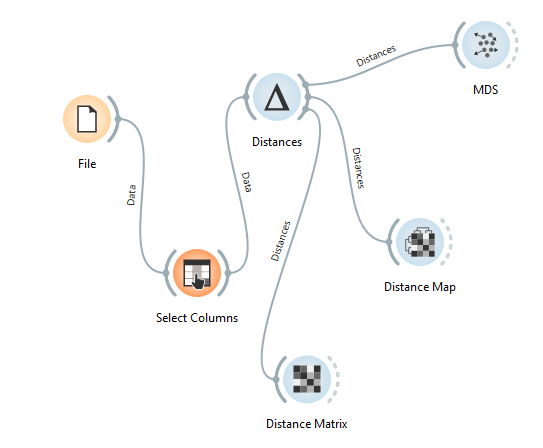

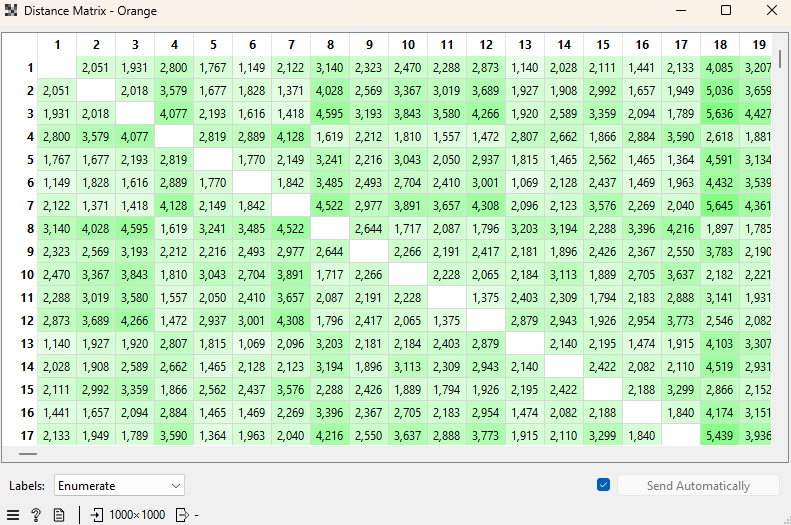

**Hasil:**  
Orange menghasilkan matriks jarak berukuran 1000 × 1000, menunjukkan jarak setiap siswa terhadap siswa lainnya.



In [1]:
!pip install gower seaborn

import pandas as pd
import gower
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Preview dataset:")
display(df.head())

distance_matrix = gower.gower_matrix(df)

distance_df = pd.DataFrame(distance_matrix, index=df.index, columns=df.index)

plt.figure(figsize=(10,8))
sns.heatmap(distance_df, cmap='viridis')
plt.title("Distance Matrix (Gower Distance)")
plt.show()

^C


  Using cached gower-0.1.2-py3-none-any.whl.metadata (3.7 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached pandas-3.0.1-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl.metadata (6.4 kB)
Using cached gower-0.1.2-py3-none-any.whl (5.2 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached pandas-3.0.1-cp312-cp312-win_amd64.whl (9.7 MB)
Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl (36.5 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using 

ModuleNotFoundError: No module named 'pandas'